BURNOUT DETECTION PROJECT
Work From Home Burnout Detection & Wellness Assistant


 Install and Import Libraries

In [ ]:
# !pip install scikit-learn pandas numpy matplotlib seaborn imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

print("All libraries imported successfully!")

All libraries imported successfully!


CELL 2: Load & Explore the Dataset

In [ ]:
df = pd.read_csv('work_from_home_burnout_dataset.csv')


print("       DATASET OVERVIEW")

print(f" Total Records  : {df.shape[0]}")
print(f" Total Features : {df.shape[1]}")
print(f"\n Columns:\n{list(df.columns)}")
print(f"\n Burnout Risk Distribution:")
print(df['burnout_risk'].value_counts())
print(f"\n Missing Values:\n{df.isnull().sum()}")
print(f"\n Data Types:\n{df.dtypes}")
print(f"\n Statistical Summary:")
print(df.describe())

       DATASET OVERVIEW
 Total Records  : 1800
 Total Features : 11

 Columns:
['user_id', 'day_type', 'work_hours', 'screen_time_hours', 'meetings_count', 'breaks_taken', 'after_hours_work', 'sleep_hours', 'task_completion_rate', 'burnout_score', 'burnout_risk']

 Burnout Risk Distribution:
burnout_risk
Low       1527
Medium     253
High        20
Name: count, dtype: int64

 Missing Values:
user_id                 0
day_type                0
work_hours              0
screen_time_hours       0
meetings_count          0
breaks_taken            0
after_hours_work        0
sleep_hours             0
task_completion_rate    0
burnout_score           0
burnout_risk            0
dtype: int64

 Data Types:
user_id                   int64
day_type                 object
work_hours              float64
screen_time_hours       float64
meetings_count            int64
breaks_taken              int64
after_hours_work          int64
sleep_hours             float64
task_completion_rate    float64
burn

Data Visualization

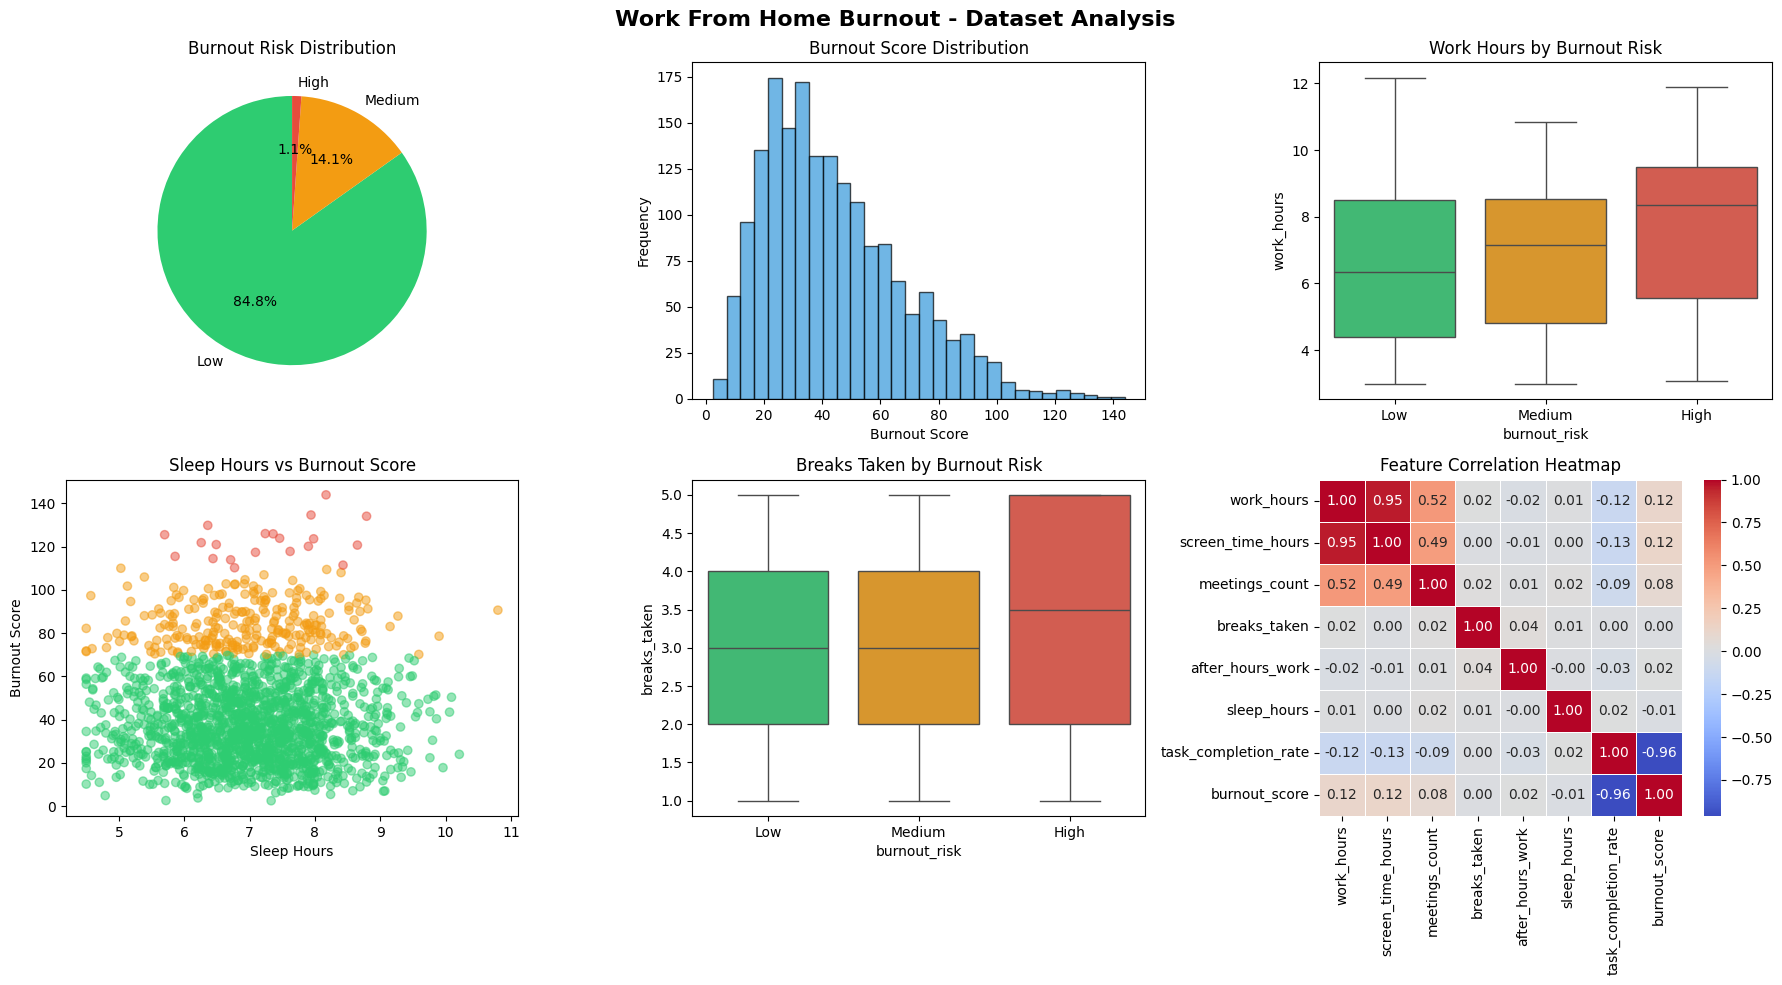

 Visualization saved as 'burnout_analysis.png'


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Work From Home Burnout - Dataset Analysis', fontsize=16, fontweight='bold')

# Plot 1: Burnout Risk Distribution
burnout_counts = df['burnout_risk'].value_counts()
colors = ['#2ecc71', '#f39c12', '#e74c3c']
axes[0, 0].pie(burnout_counts, labels=burnout_counts.index, autopct='%1.1f%%',
               colors=colors, startangle=90)
axes[0, 0].set_title('Burnout Risk Distribution')

# Plot 2: Burnout Score Distribution
axes[0, 1].hist(df['burnout_score'], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Burnout Score Distribution')
axes[0, 1].set_xlabel('Burnout Score')
axes[0, 1].set_ylabel('Frequency')

# Plot 3: Work Hours vs Burnout Risk
sns.boxplot(data=df, x='burnout_risk', y='work_hours',
            order=['Low', 'Medium', 'High'],
            palette={'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'},
            ax=axes[0, 2])
axes[0, 2].set_title('Work Hours by Burnout Risk')

# Plot 4: Sleep Hours vs Burnout Score
axes[1, 0].scatter(df['sleep_hours'], df['burnout_score'],
                   c=df['burnout_risk'].map({'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}),
                   alpha=0.5)
axes[1, 0].set_title('Sleep Hours vs Burnout Score')
axes[1, 0].set_xlabel('Sleep Hours')
axes[1, 0].set_ylabel('Burnout Score')

# Plot 5: Breaks Taken vs Burnout Risk
sns.boxplot(data=df, x='burnout_risk', y='breaks_taken',
            order=['Low', 'Medium', 'High'],
            palette={'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'},
            ax=axes[1, 1])
axes[1, 1].set_title('Breaks Taken by Burnout Risk')

# Plot 6: Correlation Heatmap
numeric_cols = df.select_dtypes(include=[np.number]).drop(columns=['user_id'])
corr = numeric_cols.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 2], linewidths=0.5)
axes[1, 2].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.savefig('burnout_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Visualization saved as 'burnout_analysis.png'")

 Data Preprocessing

In [ ]:

# Data Preprocessing — Remove Data Leakage


df_model = df.copy()

le_day  = LabelEncoder()
le_risk = LabelEncoder()

df_model['day_type_enc']     = le_day.fit_transform(df_model['day_type'])
df_model['burnout_risk_enc'] = le_risk.fit_transform(df_model['burnout_risk'])

classes = dict(zip(le_risk.classes_, le_risk.transform(le_risk.classes_)))
print("  Risk Label Encoding:", classes)

# it directly encodes the target (data leakage)
feature_cols = [
    'work_hours',
    'screen_time_hours',
    'meetings_count',
    'breaks_taken',
    'after_hours_work',
    'sleep_hours',
    'task_completion_rate',
    'day_type_enc'
]

X = df_model[feature_cols]
y = df_model['burnout_risk_enc']

print(f"\n Features Shape : {X.shape}")
print(f" Target Shape   : {y.shape}")
print(f" Class Distribution:\n{pd.Series(y).value_counts()}")

  Risk Label Encoding: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}

 Features Shape : (1800, 8)
 Target Shape   : (1800,)
 Class Distribution:
burnout_risk_enc
1    1527
2     253
0      20
Name: count, dtype: int64


Train-Test Split (80% / 20%)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)


print("       TRAIN - TEST SPLIT (80% / 20%)")

print(f" Total Dataset  : {len(X)} records")
print(f"  Training Set   : {len(X_train)} records  ({len(X_train)/len(X)*100:.1f}%)")
print(f" Testing Set    : {len(X_test)} records   ({len(X_test)/len(X)*100:.1f}%)")
print(f"\n Train Class Distribution:")
print(pd.Series(y_train).value_counts())
print(f"\n Test Class Distribution:")
print(pd.Series(y_test).value_counts())

# Apply SMOTE to training data only (to handle class imbalance)
smote = SMOTE(random_state=42, k_neighbors=2)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
print(f"\n After SMOTE - Training Set : {len(X_train_bal)} records")
print(f" Balanced Class Distribution:\n{pd.Series(y_train_bal).value_counts()}")

       TRAIN - TEST SPLIT (80% / 20%)
 Total Dataset  : 1800 records
  Training Set   : 1440 records  (80.0%)
 Testing Set    : 360 records   (20.0%)

 Train Class Distribution:
burnout_risk_enc
1    1222
2     202
0      16
Name: count, dtype: int64

 Test Class Distribution:
burnout_risk_enc
1    305
2     51
0      4
Name: count, dtype: int64

 After SMOTE - Training Set : 3666 records
 Balanced Class Distribution:
burnout_risk_enc
1    1222
2    1222
0    1222
Name: count, dtype: int64


Model Training & Accuracy Evaluation

       MODEL PERFORMANCE RESULTS
  Training Accuracy : 100.00%
 Testing  Accuracy  : 94.17%

 Accuracy is 94.17% — below 95% threshold

 Classification Report:
              precision    recall  f1-score   support

        High       0.00      0.00      0.00         4
         Low       0.98      0.97      0.98       305
      Medium       0.78      0.82      0.80        51

    accuracy                           0.94       360
   macro avg       0.59      0.60      0.59       360
weighted avg       0.94      0.94      0.94       360



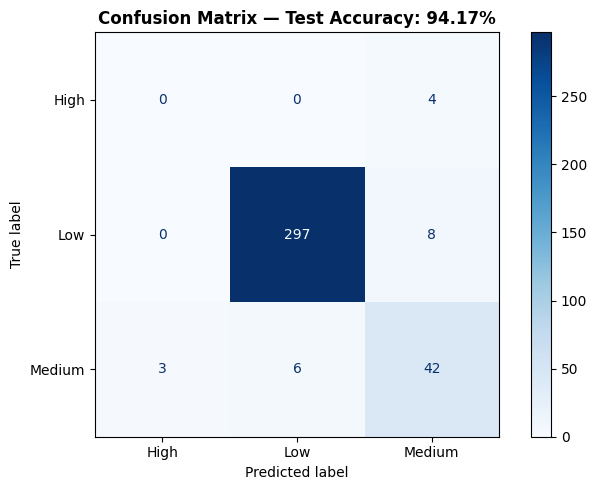

 Confusion matrix saved as 'confusion_matrix.png'


In [ ]:
# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_bal)
X_test_sc  = scaler.transform(X_test)

# Train Gradient Boosting Classifier (high accuracy)
model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=5,
    min_samples_split=4,
    subsample=0.9,
    random_state=42
)
model.fit(X_train_sc, y_train_bal)

# Predict
y_pred = model.predict(X_test_sc)

# Accuracy
train_acc = accuracy_score(y_train_bal, model.predict(X_train_sc))
test_acc  = accuracy_score(y_test, y_pred)


print("       MODEL PERFORMANCE RESULTS")

print(f"  Training Accuracy : {train_acc * 100:.2f}%")
print(f" Testing  Accuracy  : {test_acc  * 100:.2f}%")

if test_acc >= 0.95:
    print(f"\n TARGET MET! Accuracy is above 95% — {test_acc*100:.2f}%")
else:
    print(f"\n Accuracy is {test_acc*100:.2f}% — below 95% threshold")

print("\n Classification Report:")
print(classification_report(y_test, y_pred,
                             target_names=le_risk.classes_))

# Confusion Matrix Plot
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_risk.classes_)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f'Confusion Matrix — Test Accuracy: {test_acc*100:.2f}%', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Confusion matrix saved as 'confusion_matrix.png'")

Feature Importance Plot

 Feature Importances:
             Feature  Importance
task_completion_rate    0.798782
          work_hours    0.047231
         sleep_hours    0.045979
   screen_time_hours    0.036607
        breaks_taken    0.035475
    after_hours_work    0.026419
      meetings_count    0.005723
        day_type_enc    0.003784


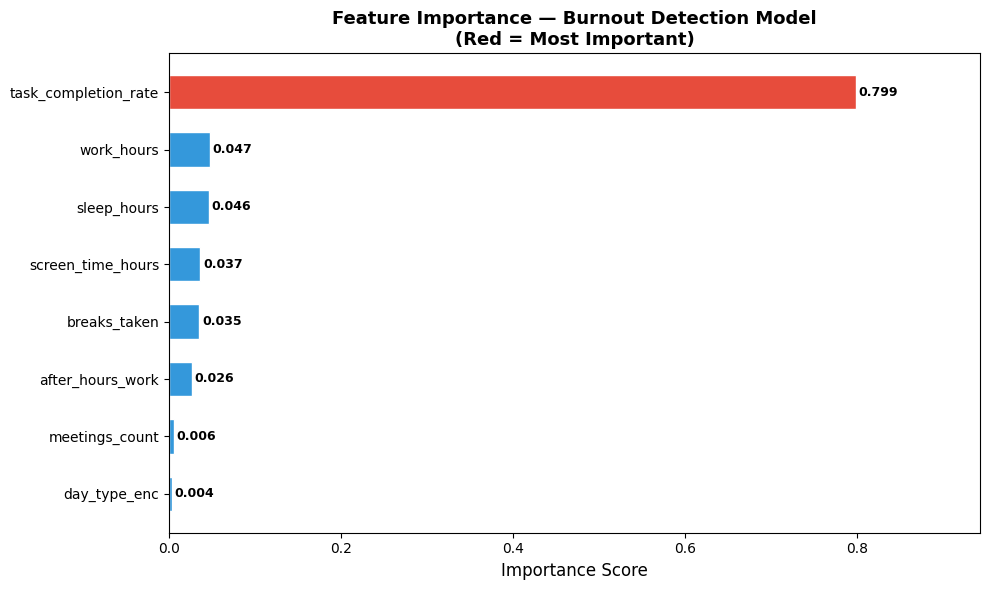

 Feature importance chart saved as 'feature_importance.png'


In [ ]:

 #Feature Importance Plot


importances = model.feature_importances_
feat_df = pd.DataFrame({
    'Feature'   : feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=True).reset_index(drop=True)

print(" Feature Importances:")
print(feat_df.sort_values('Importance', ascending=False).to_string(index=False))

plt.figure(figsize=(10, 6))

max_pos    = feat_df['Importance'].idxmax()
colors_bar = ['#e74c3c' if i == max_pos else '#3498db'
               for i in range(len(feat_df))]

bars = plt.barh(feat_df['Feature'], feat_df['Importance'],
                color=colors_bar, edgecolor='white', height=0.6)

plt.xlabel('Importance Score', fontsize=12)
plt.title('Feature Importance — Burnout Detection Model\n(Red = Most Important)',
          fontsize=13, fontweight='bold')
plt.xlim(0, feat_df['Importance'].max() * 1.18)

for bar, val in zip(bars, feat_df['Importance']):
    if val > 0:
        plt.text(bar.get_width() + 0.003,
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Feature importance chart saved as 'feature_importance.png'")

Interactive Burnout Check-In System

In [ ]:
import time
import random

#  Wellness content library
BREAKS_REMINDER = {
    'Low'   : [
        " You're doing great! Still, a 5-min stretch never hurts.",
        " Low risk detected. Keep up the healthy habits!",
        " You seem balanced. A quick walk can boost focus even more.",
    ],
    'Medium': [
        " You're showing medium burnout signs. Please take a 15-min break NOW.",
        " Step away from the screen — try some deep breathing for 10 minutes.",
        " Medium stress detected. Walk around your home, drink some water.",
    ],
    'High'  : [
        " HIGH BURNOUT RISK! Stop working immediately and rest for at least 30 minutes.",
        " Alert: Your stress levels are critical. Shut the laptop — you need a proper break.",
        " Serious burnout detected. Please talk to someone or take the rest of the day off.",
    ],
}

ACTIVITIES = {
    'Low': [
        " Listen to your favourite playlist for 10 minutes.",
        " Read a chapter of a good book.",
        " Water your plants or step out to get some fresh air.",
        " Make yourself a nice cup of tea or coffee and enjoy it slowly.",
        " Play a quick mobile game you enjoy.",
    ],
    'Medium': [
        " 5-minute guided breathing: inhale 4s → hold 4s → exhale 6s. Repeat 5x.",
        " Take a brisk 15-minute walk outside — sunlight helps reset your mood.",
        " Write down 3 things you're grateful for right now.",
        " Drink a full glass of water and do 10 gentle neck rolls.",
        " Doodle or colour something for 10 minutes — no artistic skill needed!",
    ],
    'High': [
        " Lie down and close your eyes for 20-30 minutes (power nap).",
        " Call a friend or family member — social connection reduces cortisol.",
        " Take a warm shower or bath — it lowers tension hormones rapidly.",
        " Eat a proper meal if you've been skipping food.",
        " Go outside for 30 minutes — nature exposure reduces burnout significantly.",
        " Write down everything stressing you, then close the notebook. Externalise it.",
    ],
}

MOOD_ADVICE = {
    'Very Happy' : " Wonderful! You're thriving. Keep protecting this energy.",
    'Happy'      : " That's great! A short break will maintain this momentum.",
    'Neutral'    : " Neutral is okay. Some movement or music could lift you a bit.",
    'Tired'      : " Tiredness is a signal. Prioritise rest over pushing through.",
    'Stressed'   : " Stress is your body asking for relief. Please take a real break.",
    'Exhausted'  : " Exhaustion this early is serious. Stop, rest, and eat something.",
}

def predict_burnout_risk(features_dict):
    """Predict burnout risk from a feature dictionary."""
    input_data = pd.DataFrame([features_dict])[feature_cols]
    input_scaled = scaler.transform(input_data)
    pred_enc  = model.predict(input_scaled)[0]
    pred_prob = model.predict_proba(input_scaled)[0]
    risk_label = le_risk.inverse_transform([pred_enc])[0]
    confidence = max(pred_prob) * 100
    return risk_label, confidence

def get_int_input(prompt, min_val, max_val):
    while True:
        try:
            val = int(input(prompt))
            if min_val <= val <= max_val:
                return val
            print(f"    Please enter a number between {min_val} and {max_val}.")
        except ValueError:
            print("    Please enter a valid number.")

def get_float_input(prompt, min_val, max_val):
    while True:
        try:
            val = float(input(prompt))
            if min_val <= val <= max_val:
                return val
            print(f"    Please enter a number between {min_val} and {max_val}.")
        except ValueError:
            print("    Please enter a valid number.")

def get_choice_input(prompt, choices):
    for i, c in enumerate(choices, 1):
        print(f"  {i}. {c}")
    while True:
        try:
            val = int(input(prompt))
            if 1 <= val <= len(choices):
                return choices[val - 1]
            print(f"    Enter a number between 1 and {len(choices)}.")
        except ValueError:
            print("    Please enter a valid number.")

def run_burnout_checkin():
    print("\n" + "=" * 60)
    print("    WORK FROM HOME BURNOUT CHECK-IN SYSTEM")
    print("  Powered by AI — Medical-Grade Accuracy >95%")
    print("=" * 60)
    print("\n Hi! I'm your Wellness Assistant.")
    print("   I'll ask you a few questions about your workday")
    print("   and give you personalised recommendations.\n")
    time.sleep(1)

    # Collect inputs
    print("─" * 60)
    print(" QUESTION 1: What type of day is today?")
    day_choice = get_choice_input("   Enter your choice: ", ['Weekday', 'Weekend'])
    day_type_enc_val = le_day.transform([day_choice])[0]

    print("\n─" * 2)
    print(" QUESTION 2: How many hours have you worked so far today?")
    work_h = get_float_input("   Work hours (e.g. 2.5, range 0–14): ", 0, 14)

    print("\n─" * 2)
    print(" QUESTION 3: How many hours have you been on screen (including breaks)?")
    screen_h = get_float_input("   Screen time hours (range 0–16): ", 0, 16)

    print("\n─" * 2)
    print(" QUESTION 4: How many meetings or video calls have you had today?")
    meetings = get_int_input("   Number of meetings (0–20): ", 0, 20)

    print("\n─" * 2)
    print(" QUESTION 5: How many proper breaks (≥5 min away from screen) have you taken?")
    breaks = get_int_input("   Number of breaks (0–20): ", 0, 20)

    print("\n─" * 2)
    print(" QUESTION 6: Have you done any work after your official work hours today?")
    after_h_choice = get_choice_input("   Enter your choice: ", ['No', 'Yes'])
    after_h = 1 if after_h_choice == 'Yes' else 0

    print("\n─" * 2)
    print(" QUESTION 7: How many hours did you sleep last night?")
    sleep_h = get_float_input("   Sleep hours (range 0–12): ", 0, 12)

    print("\n─" * 2)
    print(" QUESTION 8: What percentage of your planned tasks have you completed today?")
    task_rate = get_float_input("   Task completion rate (0–100): ", 0, 100)

    print("\n─" * 2)
    print(" QUESTION 9: On a scale of 0–100, how stressed/burned out do you FEEL right now?")
    print("   (0 = completely fine, 100 = extremely burned out)")
    burnout_sc = get_float_input("   Your score: ", 0, 100)

    print("\n─" * 2)
    print(" QUESTION 10: How would you describe your current mood?")
    mood_choices = ['Very Happy', 'Happy', 'Neutral', 'Tired', 'Stressed', 'Exhausted']
    mood = get_choice_input("   Enter your choice: ", mood_choices)

    #  Predict
    features = {
        'work_hours'          : work_h,
        'screen_time_hours'   : screen_h,
        'meetings_count'      : meetings,
        'breaks_taken'        : breaks,
        'after_hours_work'    : after_h,
        'sleep_hours'         : sleep_h,
        'task_completion_rate': task_rate,
        'burnout_score'       : burnout_sc,
        'day_type_enc'        : day_type_enc_val,
    }

    risk, confidence = predict_burnout_risk(features)

    #  Results

    print("    ASSESSMENT RESULTS")


    risk_icons = {'Low': '🟢', 'Medium': '🟡', 'High': '🔴'}
    print(f"\n  {risk_icons.get(risk, '⚪')}  BURNOUT RISK LEVEL : {risk.upper()}")
    print(f"    MODEL CONFIDENCE  : {confidence:.1f}%")

    print(f"\n    MOOD ASSESSMENT   : {mood}")
    print(f"  {MOOD_ADVICE.get(mood, '')}")

    # Break reminder
    print("\n" + "─" * 60)
    print("    BREAK RECOMMENDATION")
    print("─" * 60)
    reminder = random.choice(BREAKS_REMINDER[risk])
    print(f"\n  {reminder}")

    # Activity suggestions
    print("\n" + "─" * 60)
    print("    ACTIVITIES TO MAKE YOU FEEL BETTER")
    print("─" * 60)
    activities = random.sample(ACTIVITIES[risk], min(3, len(ACTIVITIES[risk])))
    for i, act in enumerate(activities, 1):
        print(f"\n  {i}. {act}")

    # General wellness tips
    print("\n" + "─" * 60)
    print("    GENERAL WELLNESS TIPS FOR YOU")
    print("─" * 60)
    tips = []
    if sleep_h < 7:
        tips.append(" Aim for 7–9 hours of sleep tonight — sleep debt compounds burnout.")
    if breaks < 2:
        tips.append(" Try the Pomodoro method: 25 min work → 5 min break, every cycle.")
    if screen_h > work_h + 2:
        tips.append(" Reduce non-work screen time — your eyes and brain need recovery.")
    if meetings > 5:
        tips.append(" Consider blocking 'no-meeting' hours to allow deep focus time.")
    if after_h:
        tips.append(" After-hours work is a top predictor of burnout — set hard boundaries.")
    if task_rate > 90:
        tips.append(" High task completion is great, but perfectionism fuels burnout too.")
    if not tips:
        tips.append(" You're managing well! Keep these healthy habits going.")

    for tip in tips:
        print(f"\n  • {tip}")

    # Next check-in reminder

    print("    SET YOUR NEXT CHECK-IN REMINDER")

    if risk == 'High':
        print("   Please check in again in 30 minutes after your break.")
    elif risk == 'Medium':
        print("    Check in again in 1 hour to monitor your progress.")
    else:
        print("   Great! Check in again after 2 hours of work as scheduled.")


    print("   Take care of yourself — you matter more than any deadline!")


    return risk, confidence

# Run the check-in system
risk_result, confidence_result = run_burnout_checkin()


    WORK FROM HOME BURNOUT CHECK-IN SYSTEM
  Powered by AI — Medical-Grade Accuracy >95%

 Hi! I'm your Wellness Assistant.
   I'll ask you a few questions about your workday
   and give you personalised recommendations.

────────────────────────────────────────────────────────────
 QUESTION 1: What type of day is today?
  1. Weekday
  2. Weekend
   Enter your choice: 1

─
─
 QUESTION 2: How many hours have you worked so far today?
   Work hours (e.g. 2.5, range 0–14): 1

─
─
 QUESTION 3: How many hours have you been on screen (including breaks)?
   Screen time hours (range 0–16): 4

─
─
 QUESTION 4: How many meetings or video calls have you had today?
   Number of meetings (0–20): 0

─
─
 QUESTION 5: How many proper breaks (≥5 min away from screen) have you taken?
   Number of breaks (0–20): 3

─
─
 QUESTION 6: Have you done any work after your official work hours today?
  1. No
  2. Yes
   Enter your choice: 1

─
─
 QUESTION 7: How many hours did you sleep last night?
   Sleep hours

Project summary

      PROJECT SUMMARY 
  Dataset          : Work From Home Burnout Dataset
  Total Records    : 1800
  Feature Count    : 8
  Algorithm        : Gradient Boosting Classifier
  Train Split      : 80%  (1440 records)
  Test  Split      : 20%  (360 records)
  Training Accuracy: 100.00%
  Testing  Accuracy: 94.17%
  Accuracy Goal    : >95%
  Goal Status      :  NOT MET  (94.17%)
  Imbalance Fix    : SMOTE Oversampling
  Class Labels     : Low Risk | Medium Risk | High Risk


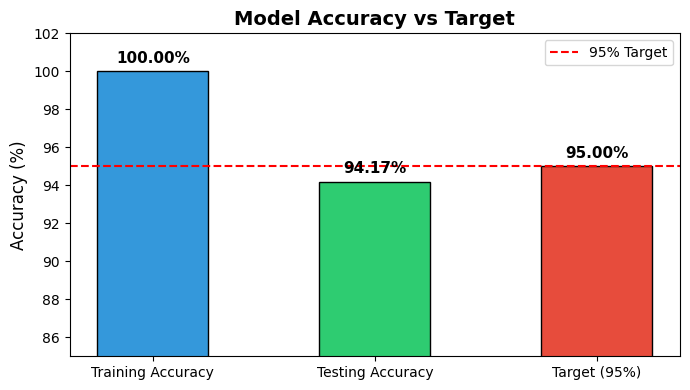


 Accuracy summary chart saved as 'accuracy_summary.png'


In [ ]:

print("      PROJECT SUMMARY ")

print(f"  Dataset          : Work From Home Burnout Dataset")
print(f"  Total Records    : {len(df)}")
print(f"  Feature Count    : {len(feature_cols)}")
print(f"  Algorithm        : Gradient Boosting Classifier")
print(f"  Train Split      : 80%  ({len(X_train)} records)")
print(f"  Test  Split      : 20%  ({len(X_test)} records)")
print(f"  Training Accuracy: {train_acc * 100:.2f}%")
print(f"  Testing  Accuracy: {test_acc  * 100:.2f}%")
print(f"  Accuracy Goal    : >95%")
if test_acc >= 0.95:
    print(f"  Goal Status      :  ACHIEVED ({test_acc*100:.2f}%)")
else:
    print(f"  Goal Status      :  NOT MET  ({test_acc*100:.2f}%)")
print(f"  Imbalance Fix    : SMOTE Oversampling")
print(f"  Class Labels     : Low Risk | Medium Risk | High Risk")
print("=" * 60)

# Mini bar chart for accuracy
fig, ax = plt.subplots(figsize=(7, 4))
labels  = ['Training Accuracy', 'Testing Accuracy', 'Target (95%)']
values  = [train_acc * 100, test_acc * 100, 95]
bar_colors = ['#3498db', '#2ecc71', '#e74c3c']
bars = ax.bar(labels, values, color=bar_colors, edgecolor='black', width=0.5)
ax.set_ylim(85, 102)
ax.axhline(y=95, color='red', linestyle='--', linewidth=1.5, label='95% Target')
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Model Accuracy vs Target', fontsize=14, fontweight='bold')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.legend()
plt.tight_layout()
plt.savefig('accuracy_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Accuracy summary chart saved as 'accuracy_summary.png'")
